In [ ]:
import pandas as pd
import numpy as np
# for visul
import matplotlib.pyplot as plt
import seaborn as sns
# for model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/linear Regression model/student_scores.csv')
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [ ]:
df.tail()

,Hours,Scores
20,2.7,30
21,4.8,54
22,3.8,35
23,6.9,76
24,7.8,86


In [ ]:
df.shape

(25, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [ ]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
df.isnull().sum()

,0
Hours,0
Scores,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.corr()

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


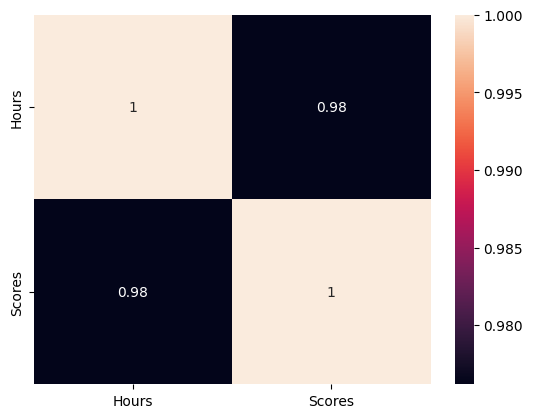

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.show()

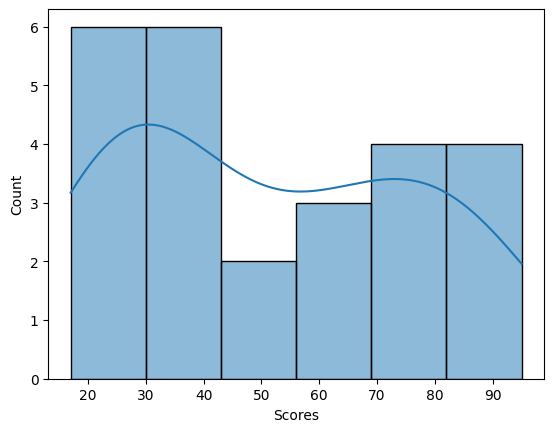

In [ ]:
sns.histplot(df['Scores'], kde=True)
plt.show()

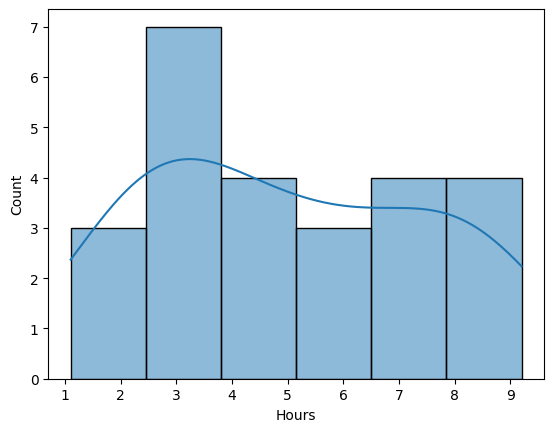

In [ ]:
sns.histplot(df['Hours'], kde=True)
plt.show()

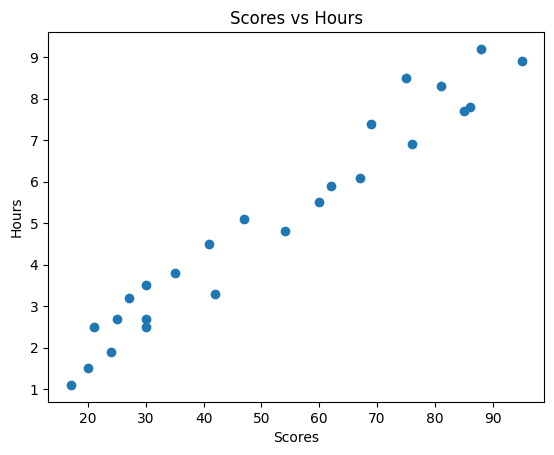

In [ ]:
plt.scatter(df['Scores'], df['Hours'])
plt.xlabel("Scores")
plt.ylabel("Hours")
plt.title("Scores vs Hours")
plt.show()

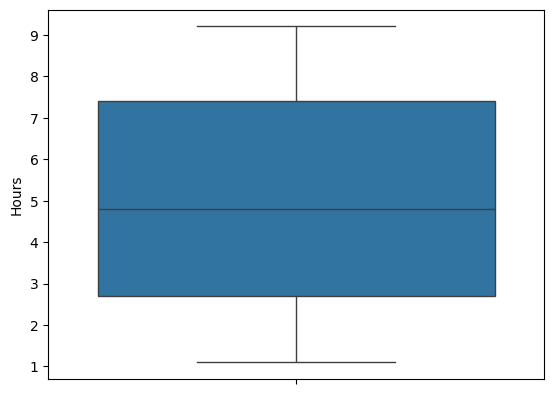

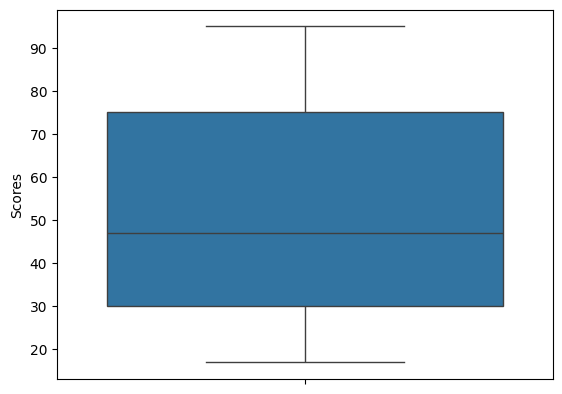

In [ ]:
sns.boxplot(df['Hours'])
plt.show()

sns.boxplot(df['Scores'])
plt.show()

In [ ]:
X = df[['Hours']]
Y = df['Scores']

In [ ]:
print(type(X))
print(X.shape)

<class 'pandas.core.frame.DataFrame'>
(25, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# model = LinearRegression()
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[83.18814104 27.03208774 27.03208774 69.63323162 59.95115347]


Evaluate Model

In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9678055545167994


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 3.9207511902099244


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 18.943211722315272


Scores=(Slope×Hours)+Intercept

In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 9.682078154455697
Intercept: 2.826892353899737


In [ ]:
new_Hours = [[30]]

predicted_Scores = model.predict(new_Hours)

print("Predicted Scores:", predicted_Scores[0])

Predicted Scores: 293.28923698757063


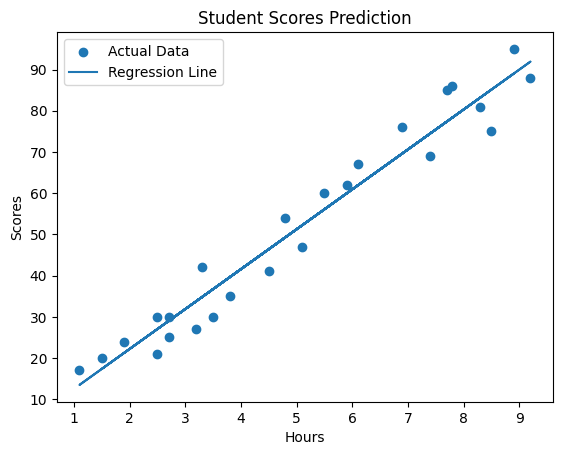

In [ ]:
import matplotlib.pyplot as plt

# Reshape X to match the format used for training
X_reshaped = X.values.reshape(-1, 1)

plt.scatter(X, Y, label="Actual Data")

plt.plot(X, model.predict(X_reshaped), label="Regression Line")

plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Student Scores Prediction")

plt.legend()
plt.show()

**bold text**## Model Performance: The Topper's Summary

**Goal:** Predict student scores based on study hours.

---

### Key Metrics:

*   **R2 Score: `0.97` (97%)**
    *   **Meaning:** 97% of score changes are explained by study hours. (Basically, our model gets it!)

*   **MAE: `3.92` points**
    *   **Meaning:** On average, our prediction is only off by about 4 points. (Pretty accurate!)

*   **MSE: `18.94`**
    *   **Meaning:** Low value, so no huge prediction screw-ups. (Good, no big errors!)

---

### Final Grade: **EXCELLENT!**

This model is fantastic for predicting student scores from study hours. It's accurate and reliable.

## Actual vs. Predicted Scores Plot

This plot helps visualize how well the model's predictions align with the actual values in the test set. A good model will have its predicted points close to the diagonal line, indicating that `y_pred` is close to `y_test`.

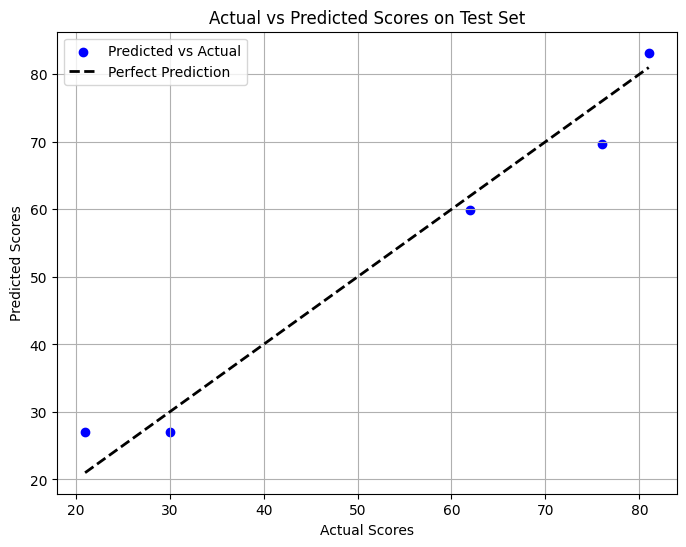

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Scores on Test Set')
plt.legend()
plt.grid(True)
plt.show()